In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.metrics import r2_score,mean_squared_error

In [8]:
df=pd.read_csv(r"C:\Users\mahes\Downloads\housing[1].csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)

C:\Users\mahes\AppData\Local\Temp\ipykernel_20584\2576143001.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)


In [13]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [15]:
df=pd.get_dummies(df,columns=['ocean_proximity'],drop_first=True)

In [16]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [17]:
y=df['median_house_value']
x=df.drop('median_house_value',axis=1)

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [58]:
model=RandomForestRegressor(n_estimators=99,random_state=42)
model.fit(x_train,y_train)

,n_estimators,99
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
y_pred=model.predict(x_test)

In [60]:
r2=r2_score(y_test,y_pred)

In [61]:
mse=mean_squared_error(y_test,y_pred)

In [62]:
rmse=np.sqrt(mse)

In [67]:
print("="*45)
print("House Price  Random Foresrt Results")
print("="*45)
print(f" R2 Score : {r2:.4f}")
print(f" RMSE     : ${rmse:,.0f}")
print(f" MSE      : {mse:,.0f}")
print("="*45)


House Price  Random Foresrt Results
 R2 Score : 0.8164
 RMSE     : $49,047
 MSE      : 2,405,562,607


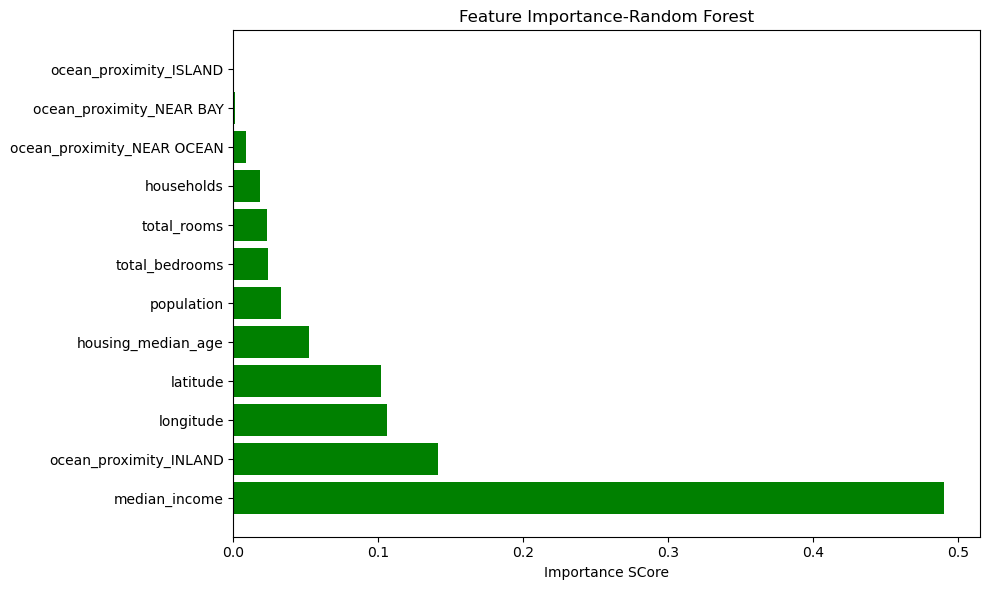

In [65]:
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":model.feature_importances_}).sort_values("Importance",ascending=False)
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"],
         importance["Importance"],
         color="green")
plt.xlabel("Importance SCore")
plt.title("Feature Importance-Random Forest")
plt.tight_layout()
plt.show()




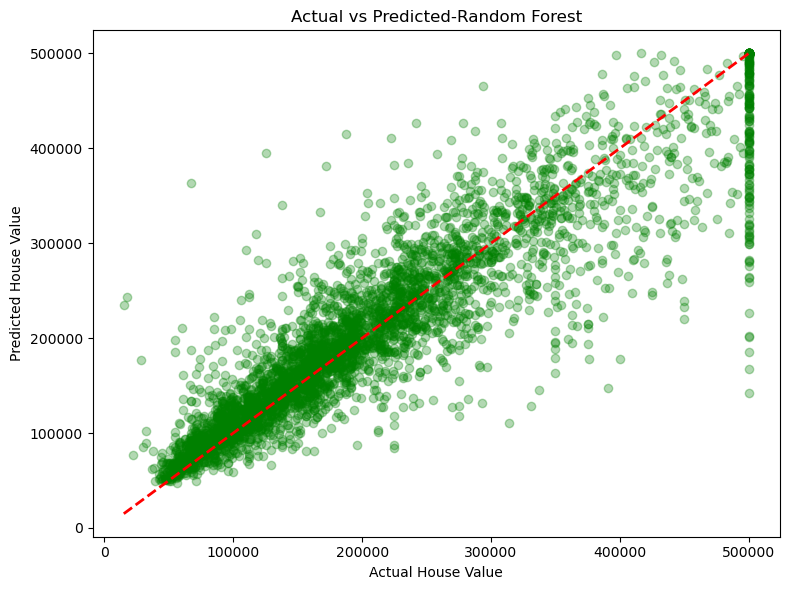

In [66]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.3,color="green")
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],'r--',linewidth=2)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted-Random Forest")
plt.tight_layout()
plt.show()

In [68]:
print("="*45)
print("Model Comparison")
print("="*45)
print(f" LinearRegression : 0.6254")
print(f" Random Forest   : {r2:.4f}")
print("="*45)

Model Comparison
 LinearRegression : 0.6254
 Random Forest   : 0.8164
